# Task 3.1 — Demand Map Construction

Build a publication-quality composite map of NE megaregion freight demand,
infrastructure corridors, and interface nodes as visual input for region clustering.

**Subtasks:**
- 3.1.1 EDA & Commodity Preprocessing
- 3.1.2 County Annual Freight Throughput
- 3.1.3 NE County Freight Demand Heatmap
- 3.1.4 Road & Rail Network Preprocessing
- 3.1.5 Composite Demand + Infrastructure + Node Map
- 3.1.6 Intermediate File Cleanup

In [5]:
# Imports and path setup
import warnings
warnings.filterwarnings('ignore')

import io
import os
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

DATA_RAW = Path('../Data/Task1/raw.parquet')
DATA_TASK2 = Path('../Data/Task2')
DATA_TASK3 = Path('../Data/Task3')
RAW_DIR = DATA_TASK3 / 'raw'
RAW_CENSUS_DIR = RAW_DIR / 'census_counties'
RAW_ROADS_DIR = RAW_DIR / 'roads'
RAW_RAILS_DIR = RAW_DIR / 'rails'
DERIVED_DIR = DATA_TASK3 / 'derived'
CACHE_DIR = DATA_TASK3 / 'cache'
FIGURES_DIR = DATA_TASK3 / 'figures'

for path in [DATA_TASK3, RAW_DIR, RAW_CENSUS_DIR, RAW_ROADS_DIR, RAW_RAILS_DIR, DERIVED_DIR, CACHE_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# NE megaregion states (FIPS codes and abbreviations)
NE_STATES = {'WV', 'VA', 'MD', 'DE', 'DC', 'PA', 'NY', 'NJ', 'CT', 'MA', 'NH', 'VT', 'ME', 'RI'}
NE_STATE_FIPS = {'54','51','24','10','11','42','36','34','09','25','33','50','23','44'}
NE_BBOX = dict(minx=-80.5, miny=36.5, maxx=-66.9, maxy=47.5)

HEATMAP_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'freight_teal',
    ['#f4fbfd', '#dbf0f3', '#b8dfe4', '#86c7d0', '#4ea6b7', '#2f7f96']
)

NODE_STYLE = {
    'global': {
        'marker': '*',
        'facecolor': '#f4b942',
        'edgecolor': '#6f4b00',
        'textcolor': '#4a3200',
        'size_range': (220, 620),
        'label': 'Global nodes'
    },
    'continental': {
        'marker': 'o',
        'facecolor': '#0f766e',
        'edgecolor': '#073b39',
        'textcolor': '#073b39',
        'size_range': (130, 420),
        'label': 'Continental nodes'
    },
    'national': {
        'marker': '^',
        'facecolor': '#2563eb',
        'edgecolor': '#173b7a',
        'textcolor': '#173b7a',
        'size_range': (90, 280),
        'label': 'National nodes'
    },
    'national_ne': {
        'marker': 'D',
        'facecolor': '#7c3aed',
        'edgecolor': '#3b1a7a',
        'textcolor': '#3b1a7a',
        'size_range': (90, 280),
        'label': 'NE national gateways'
    },
}

GLOBAL_NODE_COORDS = {
    'Hampton Roads, VA': {'lat': 36.9468, 'lon': -76.3122},
    'Philadelphia, PA': {'lat': 39.9526, 'lon': -75.1652},
    'WASHINGTON DULLES INTL': {'lat': 38.9531, 'lon': -77.4565},
    'BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL': {'lat': 39.1754, 'lon': -76.6683},
    'GENERAL EDWARD LAWRENCE LOGAN INTL': {'lat': 42.3656, 'lon': -71.0096},
    'NEWARK LIBERTY INTL': {'lat': 40.6895, 'lon': -74.1745},
    'JOHN F KENNEDY INTL': {'lat': 40.6413, 'lon': -73.7781},
    'PHILADELPHIA INTL': {'lat': 39.8744, 'lon': -75.2424},
    'PITTSBURGH INTL': {'lat': 40.4914, 'lon': -80.2329},
}

CONTINENTAL_NODE_COORDS = {
    'Buffalo Niagara Falls': {'lat': 42.9067, 'lon': -78.9053},
    'Champlain Rouses Point': {'lat': 44.9862, 'lon': -73.3655},
    'Alexandria Bay': {'lat': 44.3359, 'lon': -75.9177},
    'Derby Line': {'lat': 45.0064, 'lon': -72.0982},
    'Highgate Springs': {'lat': 45.0158, 'lon': -73.0856},
    'Houlton': {'lat': 46.1262, 'lon': -67.8402},
    'Jackman': {'lat': 45.6227, 'lon': -70.2589},
    'Calais': {'lat': 45.1889, 'lon': -67.2797},
}

NODE_LABEL_ALIASES = {
    'Hampton Roads, VA': 'Hampton Roads',
    'Philadelphia, PA': 'Philadelphia Port',
    'WASHINGTON DULLES INTL': 'IAD',
    'BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL': 'BWI',
    'GENERAL EDWARD LAWRENCE LOGAN INTL': 'BOS',
    'NEWARK LIBERTY INTL': 'EWR',
    'JOHN F KENNEDY INTL': 'JFK',
    'PHILADELPHIA INTL': 'PHL Air',
    'PITTSBURGH INTL': 'PIT',
    'Buffalo Niagara Falls': 'Buffalo-Niagara',
    'Champlain Rouses Point': 'Champlain',
    'Alexandria Bay': 'Alexandria Bay',
    'Derby Line': 'Derby Line',
    'Highgate Springs': 'Highgate Springs',
    'Houlton': 'Houlton',
    'Jackman': 'Jackman',
    'Calais': 'Calais',
}

STATE_ABBR_TO_FIPS = {
    'AL':'01','AK':'02','AZ':'04','AR':'05','CA':'06','CO':'08','CT':'09','DE':'10',
    'DC':'11','FL':'12','GA':'13','HI':'15','ID':'16','IL':'17','IN':'18','IA':'19',
    'KS':'20','KY':'21','LA':'22','ME':'23','MD':'24','MA':'25','MI':'26','MN':'27',
    'MS':'28','MO':'29','MT':'30','NE':'31','NV':'32','NH':'33','NJ':'34','NM':'35',
    'NY':'36','NC':'37','ND':'38','OH':'39','OK':'40','OR':'41','PA':'42','RI':'44',
    'SC':'45','SD':'46','TN':'47','TX':'48','UT':'49','VT':'50','VA':'51','WA':'53',
    'WV':'54','WI':'55','WY':'56',
}

NON_CONTIGUOUS_STATE_FIPS = {'02', '15', '60', '66', '69', '72', '78'}

def scale_marker_sizes(values, min_size, max_size):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    if np.nanmax(values) == np.nanmin(values):
        return np.full(values.shape, (min_size + max_size) / 2.0)
    normed = (values - np.nanmin(values)) / (np.nanmax(values) - np.nanmin(values))
    return min_size + np.sqrt(normed) * (max_size - min_size)

def attach_coordinates(df, coord_lookup):
    coord_df = pd.DataFrame.from_dict(coord_lookup, orient='index').rename_axis('node_name').reset_index()
    merged = df.merge(coord_df, on='node_name', how='left')
    merged['display_name'] = merged['node_name'].map(NODE_LABEL_ALIASES).fillna(merged['node_name'])
    return merged

def draw_highlighted_lines(gdf, ax, halo_color, line_color, halo_width, line_width, linestyle='-'):
    if gdf is None or len(gdf) == 0:
        return
    gdf.plot(ax=ax, color=halo_color, linewidth=halo_width, alpha=0.95, linestyle=linestyle, zorder=3)
    gdf.plot(ax=ax, color=line_color, linewidth=line_width, alpha=0.98, linestyle=linestyle, zorder=4)

def plot_node_markers(ax, nodes, tier, annotate=True, fontsize=6.2, text_offset=(5, 5), zorder=7):
    if nodes is None or len(nodes) == 0:
        return None
    style = NODE_STYLE[tier]
    sizes = scale_marker_sizes(nodes['tons_2025'], *style['size_range'])
    scatter = ax.scatter(
        nodes['lon'],
        nodes['lat'],
        marker=style['marker'],
        s=sizes,
        c=style['facecolor'],
        edgecolors=style['edgecolor'],
        linewidths=1.5,
        alpha=0.96,
        zorder=zorder,
        label=style['label'],
    )
    if annotate:
        for row in nodes.itertuples():
            ax.annotate(
                row.display_name,
                xy=(row.lon, row.lat),
                xytext=text_offset,
                textcoords='offset points',
                fontsize=fontsize,
                color=style['textcolor'],
                fontweight='bold',
                zorder=zorder + 1,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white', alpha=0.95)],
            )
    return scatter

print('Imports OK')
print(f'Task 3 dir: {DATA_TASK3.resolve()}')


Imports OK
Output dir: /Users/tianyihu/Documents/Dev/Python/Projects/ISYE6339_Case2/Data/Task3


## 3.1.1 — EDA and Commodity Preprocessing

Load the full NE O-D parquet, explore distributions, then apply the commodity filter:

$$\text{Exclude: } \texttt{sctg1014} \cup \texttt{sctg1519} \quad \text{(non-palletizable bulk)}$$

Remaining commodity groups: `sctg0109` (agriculture), `sctg2033` (chemical/wood/metals), `sctg3499` (manufactured/mixed freight).

In [6]:
# Load raw O-D matrix
df = pd.read_parquet(DATA_RAW)
print(f'Raw shape: {df.shape}')
print(f'Dtypes:\n{df.dtypes}')
print(f'\nNull counts:\n{df.isnull().sum()}')

Raw shape: (33404629, 7)
Dtypes:
origin_county_fips      int64
dest_county_fips        int64
mode                    int64
sctgG5                 object
trade_type              int64
tons_2025             float64
tons_2030             float64
dtype: object

Null counts:
origin_county_fips    0
dest_county_fips      0
mode                  0
sctgG5                0
trade_type            0
tons_2025             0
tons_2030             0
dtype: int64


In [7]:
# EDA — categorical columns
for col in ['mode', 'sctgG5', 'trade_type']:
    print(f'--- {col} ---')
    print(df[col].value_counts().to_string())
    print()

# EDA — numeric columns
print('--- tons_2025 / tons_2030 statistics ---')
print(df[['tons_2025','tons_2030']].describe(percentiles=[0.05,0.25,0.5,0.75,0.95]).to_string())

--- mode ---
mode
11    17823103
5     11419888
2      3934669
6       134888
3        92081

--- sctgG5 ---
sctgG5
sctg3499    10378117
sctg2033    10110535
sctg0109     6796060
sctg1014     3107255
sctg1519     3012662

--- trade_type ---
trade_type
1    16740100
2     8401007
3     8263522

--- tons_2025 / tons_2030 statistics ---
          tons_2025     tons_2030
count  3.340463e+07  3.340463e+07
mean   9.901754e-02  1.085281e-01
std    5.140084e+00  5.686880e+00
min    0.000000e+00  0.000000e+00
5%     0.000000e+00  0.000000e+00
25%    2.044722e-06  4.052569e-07
50%    1.015194e-04  8.564232e-05
75%    2.043335e-03  2.136679e-03
95%    6.709679e-02  7.585225e-02
max    6.949208e+03  7.565118e+03


In [8]:
# Commodity filter: exclude gravel/mining (sctg1014) and coal/energy (sctg1519)
EXCLUDE_SCTG = {'sctg1014', 'sctg1519'}
n_before = len(df)
df_clean = df[~df['sctgG5'].isin(EXCLUDE_SCTG)].copy()
n_after = len(df_clean)

# Cast FIPS to zero-padded 5-char strings
df_clean['origin_county_fips'] = df_clean['origin_county_fips'].astype(str).str.zfill(5)
df_clean['dest_county_fips']   = df_clean['dest_county_fips'].astype(str).str.zfill(5)

print(f'Rows before filter : {n_before:,}')
print(f'Rows after filter  : {n_after:,}')
print(f'Dropped            : {n_before - n_after:,} ({100*(n_before-n_after)/n_before:.1f}%)')
print(f'Remaining sctgG5   : {sorted(df_clean["sctgG5"].unique())}')

Rows before filter : 33,404,629
Rows after filter  : 27,284,712
Dropped            : 6,119,917 (18.3%)
Remaining sctgG5   : ['sctg0109', 'sctg2033', 'sctg3499']


In [9]:
# Sanity check: no excluded commodities remain; FIPS are 5 chars
assert not df_clean['sctgG5'].isin(EXCLUDE_SCTG).any(), 'Excluded commodities still present'
assert df_clean['origin_county_fips'].str.len().eq(5).all(), 'Origin FIPS not 5-char'
assert df_clean['dest_county_fips'].str.len().eq(5).all(), 'Dest FIPS not 5-char'
assert n_after > 0, 'Empty dataframe after filter'

print(f'✓ Commodity filter OK — {n_after:,} rows retained')
print(f'✓ FIPS zero-padding OK')

# Save
clean_path = CACHE_DIR / 'freight_clean.parquet'
df_clean.to_parquet(clean_path, compression='snappy', index=False)
print(f'✓ Saved: {clean_path}')

✓ Commodity filter OK — 27,284,712 rows retained
✓ FIPS zero-padding OK
✓ Saved: ../Data/Task3/freight_clean.parquet


## 3.1.2 — County Annual Freight Throughput

Collapse O-D pairs into per-county **bidirectional throughput** used as demand weights
for clustering and choropleth visualization:

$$\text{throughput}_i = \underbrace{\sum_{j} T_{ij}}_{\text{outbound}} + \underbrace{\sum_{j} T_{ji}}_{\text{inbound}}$$

where $T_{ij}$ is the 2025 truck-compatible tonnage from county $i$ to county $j$.

In [10]:
# Load cleaned freight table
df_c = pd.read_parquet(CACHE_DIR / 'freight_clean.parquet')
print(f'Loaded freight_clean.parquet — {len(df_c):,} rows')

Loaded freight_clean.parquet — 27,284,712 rows


In [11]:
# Compute outbound and inbound tonnage per county
tons_out = (
    df_c.groupby('origin_county_fips')['tons_2025']
    .sum()
    .rename('tons_out')
    .reset_index()
    .rename(columns={'origin_county_fips': 'fips'})
)

tons_in = (
    df_c.groupby('dest_county_fips')['tons_2025']
    .sum()
    .rename('tons_in')
    .reset_index()
    .rename(columns={'dest_county_fips': 'fips'})
)

# Outer join on FIPS; fill NaN with 0
throughput = (
    tons_out.merge(tons_in, on='fips', how='outer')
    .fillna(0.0)
)
throughput['throughput'] = throughput['tons_in'] + throughput['tons_out']

print(f'Unique counties: {len(throughput):,}')
print(throughput[['tons_in','tons_out','throughput']].describe().to_string())

Unique counties: 3,144
            tons_in      tons_out    throughput
count   3144.000000   3144.000000   3144.000000
mean     532.644940    532.644940   1065.289880
std     2077.875675   2066.551649   4109.183197
min        0.031076      0.480580      0.645344
25%        6.412172     11.874760     19.381010
50%       20.007859     32.548171     53.512621
75%      115.561559    151.263427    266.466362
max    39124.384153  31877.722949  71002.107103


In [12]:
# Sanity checks and save
assert (throughput['throughput'] >= 0).all(), 'Negative throughput detected'
assert (throughput['throughput'] > 0).all(), 'Zero-throughput counties — check filter'
assert len(throughput) > 0, 'Empty throughput table'

tp_path = DERIVED_DIR / 'county_throughput.parquet'
throughput[['fips','tons_in','tons_out','throughput']].to_parquet(tp_path, index=False)

print(f'✓ {len(throughput):,} counties')
print(f'✓ throughput range: [{throughput["throughput"].min():,.0f}, {throughput["throughput"].max():,.0f}] thousand short tons')
print(f'✓ Saved: {tp_path}')

✓ 3,144 counties
✓ throughput range: [1, 71,002] thousand short tons
✓ Saved: ../Data/Task3/county_throughput.parquet


## 3.1.3 — NE County Freight Demand Heatmap

Choropleth map of county-level annual freight throughput over the NE megaregion.
Color ramp uses **log-norm** because freight throughput is heavily right-skewed
(a few high-volume urban counties dominate the distribution):

$$\text{color} \propto \log_{10}(\text{throughput}_i)$$

In [13]:
# Download or load US county TIGER/Line shapefile (cb_2023_us_county_500k)
TIGER_PATH = RAW_CENSUS_DIR / 'cb_2023_us_county_500k.shp'
TIGER_ZIP  = RAW_CENSUS_DIR / 'cb_2023_us_county_500k.zip'
TIGER_URL  = 'https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip'

if not TIGER_PATH.exists():
    print('Downloading Census TIGER county shapefile (~5 MB)...')
    r = requests.get(TIGER_URL, timeout=60)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(RAW_CENSUS_DIR)
    print('Downloaded and extracted.')
else:
    print('TIGER shapefile already present — skipping download.')

counties_us = gpd.read_file(TIGER_PATH)
print(f'US counties loaded: {len(counties_us)} features')
print(f'CRS: {counties_us.crs}')
print(f'Columns: {counties_us.columns.tolist()}')

TIGER shapefile already present — skipping download.
US counties loaded: 3235 features
CRS: EPSG:4269
Columns: ['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']


In [14]:
# Filter to NE megaregion states
ne_counties = counties_us[counties_us['STATEFP'].isin(NE_STATE_FIPS)].copy()
ne_counties['GEOID'] = ne_counties['GEOID'].astype(str).str.zfill(5)

# Load throughput and join
tp = pd.read_parquet(DERIVED_DIR / 'county_throughput.parquet')
ne_map = ne_counties.merge(tp, left_on='GEOID', right_on='fips', how='left')
ne_map['throughput'] = ne_map['throughput'].fillna(0.0)

# Separate state outlines for overlay
ne_states_gdf = ne_counties.dissolve(by='STATEFP').reset_index()

print(f'NE counties: {len(ne_counties)}')
print(f'NE counties with throughput data: {ne_map["throughput"].gt(0).sum()}')
print(f'Throughput range: [{ne_map["throughput"].min():,.0f}, {ne_map["throughput"].max():,.0f}]')

NE counties: 434
NE counties with throughput data: 434
Throughput range: [223, 71,002]


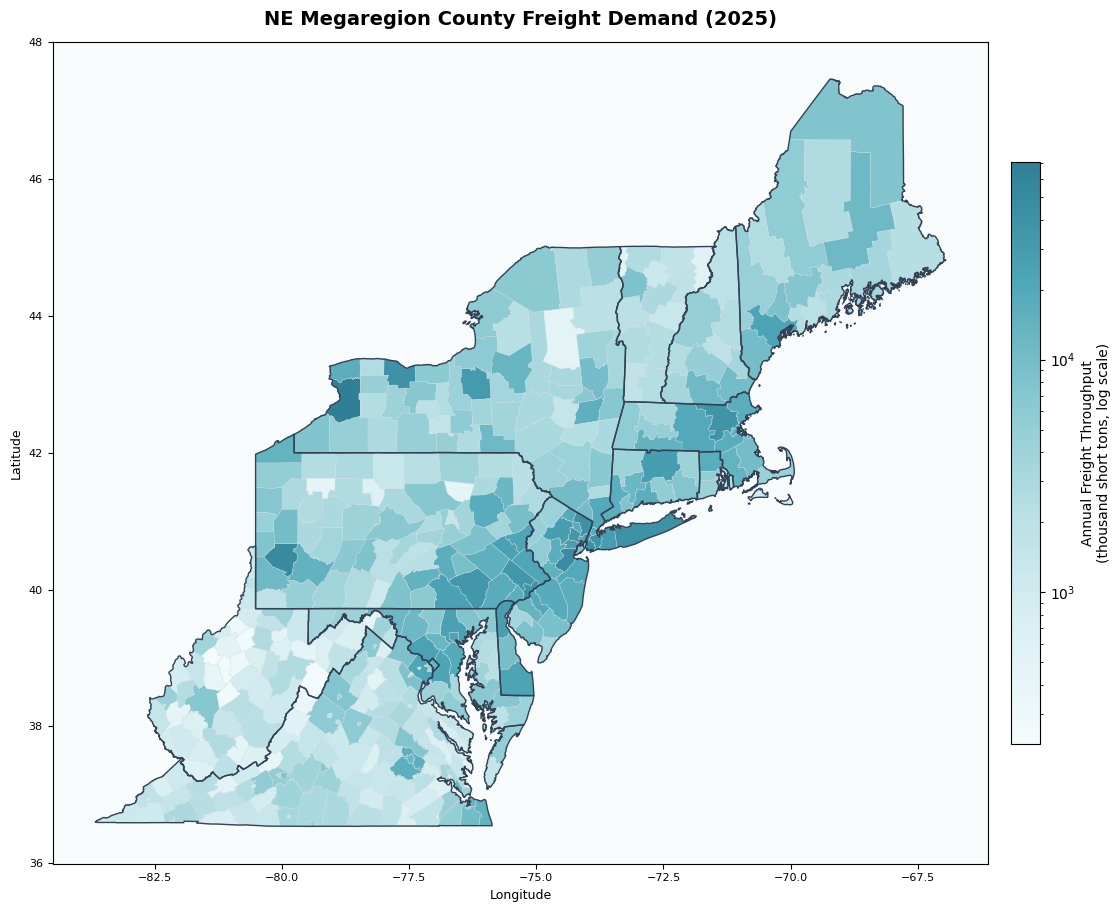

✓ Saved: ../Data/Task3/fig_demand_heatmap.png


In [15]:
# Plot choropleth — log-scale color ramp on throughput
tp_vals = ne_map['throughput'].replace(0, np.nan).dropna()
vmin, vmax = tp_vals.min(), tp_vals.max()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_facecolor('#f7fbfc')

# Counties with data — log-norm choropleth
ne_map[ne_map['throughput'] > 0].plot(
    column='throughput',
    ax=ax,
    cmap=HEATMAP_CMAP,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    linewidth=0.22,
    edgecolor='#d5dde1',
    legend=False,
    zorder=1,
)

# Counties with no data — soft neutral fill
ne_zero = ne_map[ne_map['throughput'] == 0]
if len(ne_zero) > 0:
    ne_zero.plot(ax=ax, color='#eef3f5', linewidth=0.22, edgecolor='#d5dde1', zorder=1)

# State outlines on top
ne_states_gdf.boundary.plot(ax=ax, linewidth=1.0, edgecolor='#334155', zorder=4)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=HEATMAP_CMAP, norm=LogNorm(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Annual Freight Throughput' + chr(10) + '(thousand short tons, log scale)', fontsize=10)

ax.set_title('NE Megaregion County Freight Demand (2025)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.tick_params(labelsize=8)

plt.tight_layout()
heatmap_path = FIGURES_DIR / 'fig_demand_heatmap.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {heatmap_path}')


## 3.1.4 — Road and Rail Network Preprocessing

Extract US interstates from the NTAD North American Roads dataset.
Filter criteria: `COUNTRY == 2` (US) and `CLASS == 1` (Interstate).
Clip to NE bounding box: `lon ∈ [-80.5, -66.9]`, `lat ∈ [36.5, 47.5]`.

GeoParquet format is ~3–5× smaller than shapefile and loads ~10× faster.

In [16]:
NTAD_PATH = RAW_ROADS_DIR / 'North_American_Roads.shp'

# Load interstates only (COUNTRY=2 US, CLASS=1 Interstate) using bbox filter for speed
from shapely.geometry import box as shapely_box
ne_box = shapely_box(NE_BBOX['minx'], NE_BBOX['miny'], NE_BBOX['maxx'], NE_BBOX['maxy'])

int_path = CACHE_DIR / 'ne_interstates.parquet'
if not int_path.exists():
    print('Loading NTAD Roads shapefile (full dataset ~720k rows)...')
    roads = gpd.read_file(NTAD_PATH)
    print(f'Full dataset: {len(roads):,} rows')
    print(f'COUNTRY unique: {sorted(roads["COUNTRY"].unique())}  (1=Canada, 2=US, 3=Mexico)')
    print(f'CLASS unique: {sorted(roads["CLASS"].unique())}  (1=Interstate)')

    # Filter: US interstates only
    interstates = roads[(roads['COUNTRY'] == 2) & (roads['CLASS'] == 1)].copy()
    print(f'US interstates: {len(interstates):,} segments')

    # Keep essential columns
    interstates = interstates[['ROADNUM', 'ROADNAME', 'CLASS', 'NHS', 'geometry']].copy()

    # Clip to NE bounding box
    interstates_ne = gpd.clip(interstates, ne_box)
    print(f'NE-clipped interstate segments: {len(interstates_ne):,}')

    interstates_ne.to_parquet(int_path)
    print(f'✓ Saved: {int_path}')
else:
    interstates_ne = gpd.read_parquet(int_path)
    print(f'Loaded from cache: {len(interstates_ne):,} NE interstate segments')

Loading NTAD Roads shapefile (full dataset ~720k rows)...
Full dataset: 720,055 rows
COUNTRY unique: [np.int32(1), np.int32(2), np.int32(3)]  (1=Canada, 2=US, 3=Mexico)
CLASS unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  (1=Interstate)
US interstates: 100,009 segments
NE-clipped interstate segments: 16,139
✓ Saved: ../Data/Task3/ne_interstates.parquet


In [17]:
# Sanity check — interstates
assert len(interstates_ne) > 0, 'No interstate segments in NE bounding box'
assert interstates_ne.geometry.is_valid.all(), 'Invalid geometries in interstate GeoDataFrame'
bounds = interstates_ne.total_bounds  # [minx, miny, maxx, maxy]
assert bounds[0] >= NE_BBOX['minx'] - 0.1 and bounds[2] <= NE_BBOX['maxx'] + 0.1, \
    f'Interstate segments outside NE lon bounds: {bounds}'

print(f'✓ {len(interstates_ne):,} NE interstate segments')
print(f'✓ Bounding box: {bounds.round(2)}')
print(f'✓ Unique routes: {interstates_ne["ROADNUM"].nunique()}')

✓ 16,139 NE interstate segments
✓ Bounding box: [-80.5   36.5  -67.78  46.15]
✓ Unique routes: 82


In [18]:
# Railroads — note: NTAD Roads file is road-only; railroad data not bundled
# Attempting BTS NTAD National Rail Network download
RAIL_PATH = CACHE_DIR / 'ne_railroads.parquet'
RAIL_CENSUS_URL = 'https://www2.census.gov/geo/tiger/TIGER2023/RAILS/tl_2023_us_rails.zip'

if not RAIL_PATH.exists():
    try:
        print('Downloading Census TIGER railroad shapefile...')
        r = requests.get(RAIL_CENSUS_URL, timeout=120)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            z.extractall(RAW_RAILS_DIR)
        rails_shp = list(RAW_RAILS_DIR.glob('*.shp'))[0]
        rails = gpd.read_file(rails_shp)
        print(f'Railroad dataset: {len(rails):,} features | columns: {rails.columns.tolist()}')

        rails_ne = gpd.clip(rails, ne_box)
        # Keep essential columns if they exist
        keep_cols = [c for c in ['FULLNAME', 'LINEARID', 'geometry'] if c in rails_ne.columns]
        rails_ne = rails_ne[keep_cols].copy()
        rails_ne.to_parquet(RAIL_PATH)
        print(f'✓ NE railroad segments: {len(rails_ne):,}')
        print(f'✓ Saved: {RAIL_PATH}')
        RAIL_AVAILABLE = True
    except Exception as e:
        print(f'Railroad download failed: {e}')
        print('Proceeding without railroad overlay (will note in map legend).')
        RAIL_AVAILABLE = False
else:
    rails_ne = gpd.read_parquet(RAIL_PATH)
    print(f'Loaded railroad cache: {len(rails_ne):,} NE railroad segments')
    RAIL_AVAILABLE = True

Railroad dataset: 119,857 features | columns: ['LINEARID', 'FULLNAME', 'MTFCC', 'geometry']
✓ NE railroad segments: 19,576
✓ Saved: ../Data/Task3/ne_railroads.parquet


## 3.1.5 — Composite Demand + Infrastructure + Node Map

Single publication-quality map combining:
1. **County freight demand choropleth** (log-scale, from 3.1.3)
2. **Highlighted interstate and railroad overlays**
3. **Task 2 interface node markers**
   - Global tier: gold stars, scaled by throughput
   - Continental tier: teal circles, scaled by throughput
   - National tier: blue triangles in a US inset so external nodes remain visible

Z-order: choropleth → state outlines → roads/rails → node markers → legend/inset


In [19]:
# --- Global and continental interface nodes ---
global_nodes = attach_coordinates(
    pd.read_csv(DATA_TASK2 / 'task2_global_interface_nodes_final.csv'),
    GLOBAL_NODE_COORDS,
)
continental_nodes = attach_coordinates(
    pd.read_csv(DATA_TASK2 / 'task2_continental_interface_nodes_final.csv'),
    CONTINENTAL_NODE_COORDS,
)

for tier_name, nodes in [('global', global_nodes), ('continental', continental_nodes)]:
    missing = nodes[nodes[['lat', 'lon']].isna().any(axis=1)]
    if len(missing) > 0:
        print(f'WARNING: {len(missing)} {tier_name} nodes are missing coordinates:')
        print(missing[['node_name', 'state_name']].to_string(index=False))
    else:
        print(f'✓ All {len(nodes)} {tier_name} nodes resolved with map coordinates')
    nodes['marker_size'] = scale_marker_sizes(nodes['tons_2025'], *NODE_STYLE[tier_name]['size_range'])
    print(nodes[['node_name', 'tons_2025', 'lat', 'lon']].to_string(index=False))
    print()


✓ All 9 global nodes resolved with map coordinates
                                  node_name     tons_2025     lat      lon
                          Hampton Roads, VA  20204.535156 36.9468 -76.3122
                           Philadelphia, PA  20204.535156 39.9526 -75.1652
                     WASHINGTON DULLES INTL  26581.482281 38.9531 -77.4565
BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL  15530.753693 39.1754 -76.6683
         GENERAL EDWARD LAWRENCE LOGAN INTL  19353.708448 42.3656 -71.0096
                        NEWARK LIBERTY INTL  73352.944363 40.6895 -74.1745
                        JOHN F KENNEDY INTL 236425.858134 40.6413 -73.7781
                          PHILADELPHIA INTL  92049.582462 39.8744 -75.2424
                            PITTSBURGH INTL  15948.889369 40.4914 -80.2329

✓ All 8 continental nodes resolved with map coordinates
             node_name  tons_2025     lat      lon
 Buffalo Niagara Falls   30162118 42.9067 -78.9053
Champlain Rouses Point    9776473 44.986

In [20]:
# --- National interface nodes — join FIPS to county representative points ---
nat_raw = pd.read_csv(DATA_TASK2 / 'task2_national_interface_nodes_final.csv').copy()
nat_raw['county_upper'] = nat_raw['node_name'].str.split(',').str[0].str.strip().str.upper()
nat_raw['state_fips'] = nat_raw['state_name'].str.strip().map(STATE_ABBR_TO_FIPS)

counties_us['NAME_UPPER'] = counties_us['NAME'].str.upper()
nat_merged = nat_raw.merge(
    counties_us[['GEOID', 'NAME_UPPER', 'STATEFP', 'geometry']],
    left_on=['county_upper', 'state_fips'],
    right_on=['NAME_UPPER', 'STATEFP'],
    how='left'
)
nat_merged = gpd.GeoDataFrame(nat_merged, geometry='geometry', crs='EPSG:4326')
nat_merged['label_point'] = nat_merged.geometry.representative_point()
nat_merged['lat'] = nat_merged['label_point'].y
nat_merged['lon'] = nat_merged['label_point'].x
nat_merged['display_name'] = nat_merged['node_name'].str.replace(', ', chr(10), regex=False).str.title()
nat_merged['marker_size'] = scale_marker_sizes(nat_merged['tons_2025'], *NODE_STYLE['national']['size_range'])
nat_merged['in_main_map'] = (
    nat_merged['lon'].between(NE_BBOX['minx'], NE_BBOX['maxx'])
    & nat_merged['lat'].between(NE_BBOX['miny'], NE_BBOX['maxy'])
)

unmatched = nat_merged[nat_merged['lat'].isna()]
if len(unmatched) > 0:
    print(f'WARNING: {len(unmatched)} national nodes could not be matched to TIGER:')
    print(unmatched[['node_name', 'state_name']].to_string(index=False))
else:
    print(f'✓ All {len(nat_merged)} national nodes matched to county geometries')

nat_valid = nat_merged.dropna(subset=['lat', 'lon']).copy()
print(f'National nodes inside main NE frame: {nat_valid["in_main_map"].sum()}')
print(f'National nodes shown in inset: {len(nat_valid)}')
print(nat_valid[['node_name', 'state_name', 'tons_2025', 'lat', 'lon']].to_string(index=False))


✓ All 12 national nodes matched to county geometries
National nodes inside main NE frame: 0
National nodes shown in inset: 12
      node_name state_name  tons_2025       lat         lon
      LUCAS, OH         OH  24970.404 41.574123  -83.745953
     HARRIS, TX         TX  24363.121 29.833992  -95.386403
       COOK, IL         IL  24107.610 41.814077  -87.754098
   FRANKLIN, OH         OH  21339.086 39.969484  -83.013194
   CUYAHOGA, OH         OH  21278.725 41.452405  -81.680561
   HAMILTON, OH         OH  21233.752 39.168571  -84.558185
LOS ANGELES, CA         CA  15785.006 34.265836 -118.142593
       WEBB, TX         TX  13995.279 27.732056  -99.286205
      STARK, OH         OH  12444.701 40.809430  -81.367434
  JEFFERSON, KY         KY  11356.382 38.187916  -85.655830
MECKLENBURG, NC         NC  11290.301 35.258287  -80.830593
      WAYNE, MI         MI  11273.386 42.243612  -83.333673


In [21]:
# --- NE-side national gateway counties (NE-centric bidirectional throughput) ---
# For each NE county, sum ALL national_domestic (trade_type=1) cross-boundary flows
# where one endpoint is inside NE and the other is outside — regardless of which
# specific external county is involved. Then rank top 20 by bidirectional throughput.
EXCLUDE_SCTG = {'sctg1014', 'sctg1519'}

df_raw = pd.read_parquet(DATA_RAW)
df_raw['origin_county_fips'] = df_raw['origin_county_fips'].astype(str).str.zfill(5)
df_raw['dest_county_fips']   = df_raw['dest_county_fips'].astype(str).str.zfill(5)

# Commodity filter + domestic flows only
df_nd = df_raw[
    (df_raw['trade_type'] == 1) &
    (~df_raw['sctgG5'].isin(EXCLUDE_SCTG))
].copy()

ne_prefix = NE_STATE_FIPS  # 2-char state FIPS

mask_ne_orig = df_nd['origin_county_fips'].str[:2].isin(ne_prefix)
mask_ne_dest = df_nd['dest_county_fips'].str[:2].isin(ne_prefix)

# Cross-boundary: exactly one endpoint in NE
cross = df_nd[mask_ne_orig ^ mask_ne_dest].copy()

# Outbound: NE origin → external dest → credit NE origin county
outbound = cross[mask_ne_orig & ~mask_ne_dest][['origin_county_fips','tons_2025']].rename(
    columns={'origin_county_fips': 'ne_fips', 'tons_2025': 'tons_out'})
# Inbound: external origin → NE dest → credit NE dest county
inbound  = cross[~mask_ne_orig & mask_ne_dest][['dest_county_fips','tons_2025']].rename(
    columns={'dest_county_fips': 'ne_fips', 'tons_2025': 'tons_in'})

tons_out_agg = outbound.groupby('ne_fips', as_index=False)['tons_out'].sum()
tons_in_agg  = inbound.groupby('ne_fips', as_index=False)['tons_in'].sum()

ne_gw_tons = (
    tons_out_agg.merge(tons_in_agg, on='ne_fips', how='outer')
    .fillna(0)
)
ne_gw_tons['gw_tons_2025'] = ne_gw_tons['tons_out'] + ne_gw_tons['tons_in']
ne_gw_tons = ne_gw_tons.sort_values('gw_tons_2025', ascending=False).head(20).reset_index(drop=True)

print(f'Top 20 NE counties by national_domestic cross-boundary throughput:')
print(ne_gw_tons[['ne_fips','tons_out','tons_in','gw_tons_2025']].to_string(index=False))

# Join to county geometries for map coordinates
ne_gw_merged = ne_gw_tons.merge(
    counties_us[['GEOID', 'NAME', 'STATEFP', 'geometry']],
    left_on='ne_fips', right_on='GEOID', how='left'
)
ne_gw_merged = gpd.GeoDataFrame(ne_gw_merged, geometry='geometry', crs='EPSG:4326')
ne_gw_merged['label_point'] = ne_gw_merged.geometry.representative_point()
ne_gw_merged['lat'] = ne_gw_merged['label_point'].y
ne_gw_merged['lon'] = ne_gw_merged['label_point'].x

fips_to_abbr = {v: k for k, v in STATE_ABBR_TO_FIPS.items()}
ne_gw_merged['state_abbr'] = ne_gw_merged['STATEFP'].map(fips_to_abbr)
ne_gw_merged['display_name'] = ne_gw_merged['NAME'].str.title() + ', ' + ne_gw_merged['state_abbr']
ne_gw_merged['tons_2025'] = ne_gw_merged['gw_tons_2025']
ne_gw_merged['marker_size'] = scale_marker_sizes(
    ne_gw_merged['tons_2025'], *NODE_STYLE['national_ne']['size_range']
)

ne_national_gw = ne_gw_merged.dropna(subset=['lat', 'lon']).copy()
print(f'\n✓ {len(ne_national_gw)} NE gateway counties (top 20) resolved with coordinates')
print(ne_national_gw[['display_name','tons_2025','lat','lon']].to_string(index=False))


Top 20 NE counties by national_domestic cross-boundary throughput:
ne_fips    tons_out     tons_in  gw_tons_2025
  42003 7076.805441 5676.260264  12753.065704
  36029 3395.360419 3355.200035   6750.560454
  42071 2968.339706 3759.743660   6728.083366
  42133 2100.083631 2871.380080   4971.463711
  34023 2406.870514 2170.969636   4577.840150
  34003 1970.277372 2322.510578   4292.787950
  42101 1807.680850 2242.941152   4050.622002
  42091 1813.250473 1857.747919   3670.998392
  36055 1741.505293 1925.103950   3666.609243
  42077 1137.638225 2511.121380   3648.759605
  42079 1613.593625 1960.583958   3574.177583
  42129 1798.467127 1772.770525   3571.237652
  42095 1009.120295 2324.710851   3333.831146
  25017 1230.328614 2060.367714   3290.696328
  34013 1474.307928 1816.104796   3290.412724
  36061 2170.176173 1096.207621   3266.383793
  42043 1521.147264 1717.665177   3238.812441
  42041 1311.717259 1550.878078   2862.595336
  34027 1583.962639 1277.609137   2861.571776
  42125 1547.

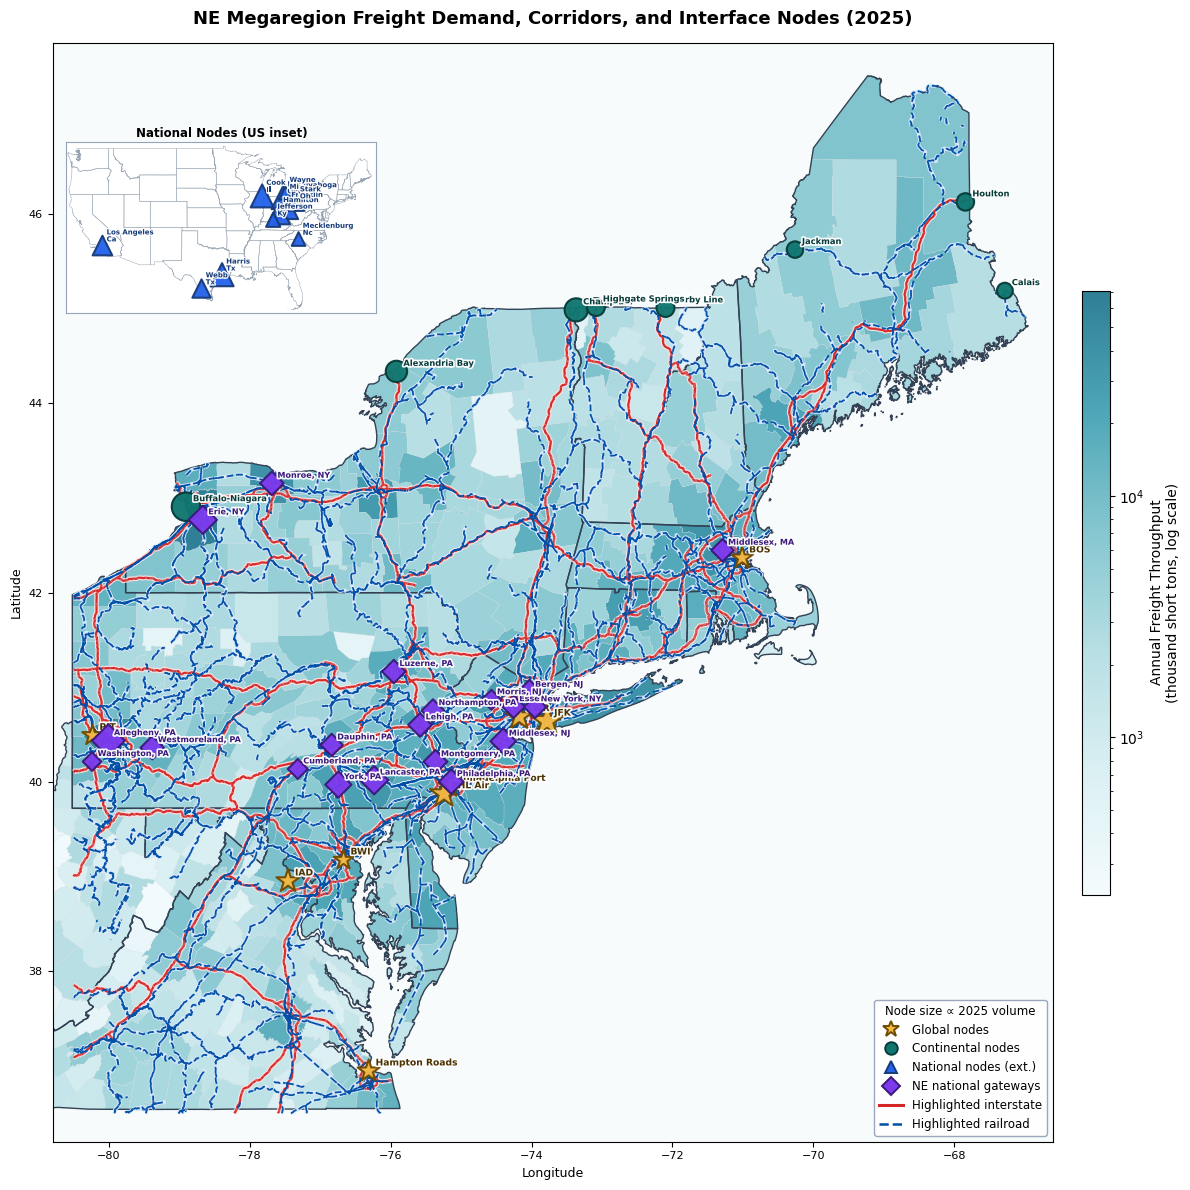

✓ Saved: ../Data/Task3/fig_composite_map.png


In [22]:
# --- Build composite map ---
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
ax.set_facecolor('#f7fbfc')

# Layer 1: County freight demand choropleth
tp_ne = ne_map[ne_map['throughput'] > 0].copy()
tp_zero = ne_map[ne_map['throughput'] == 0].copy()
vmin_c, vmax_c = tp_ne['throughput'].min(), tp_ne['throughput'].max()

tp_ne.plot(
    column='throughput',
    ax=ax,
    cmap=HEATMAP_CMAP,
    norm=LogNorm(vmin=vmin_c, vmax=vmax_c),
    linewidth=0.16,
    edgecolor='#d5dde1',
    zorder=1,
    legend=False,
)
if len(tp_zero) > 0:
    tp_zero.plot(ax=ax, color='#eef3f5', linewidth=0.16, edgecolor='#d5dde1', zorder=1)

# Layer 2: State outlines
ne_states_gdf.boundary.plot(ax=ax, linewidth=1.0, edgecolor='#334155', zorder=2)

# Layer 3: Highlighted interstate and railroad overlays
interstates_ne = gpd.read_parquet(CACHE_DIR / 'ne_interstates.parquet')
draw_highlighted_lines(
    interstates_ne, ax,
    halo_color='#ffe1e1', line_color='#d62828',
    halo_width=3.4, line_width=1.6,
)

if RAIL_PATH.exists():
    rails_ne = gpd.read_parquet(RAIL_PATH)
    draw_highlighted_lines(
        rails_ne, ax,
        halo_color='#dbeafe', line_color='#004fa7',
        halo_width=2.7, line_width=1.3,
        linestyle='--',
    )
    RAIL_AVAILABLE = True
else:
    RAIL_AVAILABLE = False

# Layer 4: Node markers on the NE map
global_valid = global_nodes.dropna(subset=['lat', 'lon']).copy()
continental_valid = continental_nodes.dropna(subset=['lat', 'lon']).copy()
national_main = nat_valid[nat_valid['in_main_map']].copy()

plot_node_markers(ax, global_valid, 'global', annotate=True, fontsize=6.6, text_offset=(5, 4), zorder=7)
plot_node_markers(ax, continental_valid, 'continental', annotate=True, fontsize=6.0, text_offset=(5, 4), zorder=7)
if len(national_main) > 0:
    plot_node_markers(ax, national_main, 'national', annotate=True, fontsize=5.8, text_offset=(4, -8), zorder=7)

# NE-side national gateway counties (on main map)
if len(ne_national_gw) > 0:
    plot_node_markers(ax, ne_national_gw, 'national_ne', annotate=True, fontsize=5.8, text_offset=(4, 4), zorder=8)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=HEATMAP_CMAP, norm=LogNorm(vmin=vmin_c, vmax=vmax_c))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.55, pad=0.02, aspect=22)
cbar.set_label('Annual Freight Throughput' + chr(10) + '(thousand short tons, log scale)', fontsize=10)

# National node inset so all external domestic nodes remain visible
inset_ax = inset_axes(ax, width='31%', height='31%', loc='upper left', borderpad=1.0)
inset_ax.set_facecolor('white')
us_states = counties_us[~counties_us['STATEFP'].isin(NON_CONTIGUOUS_STATE_FIPS)].dissolve(by='STATEFP').reset_index()
us_states.boundary.plot(ax=inset_ax, linewidth=0.35, edgecolor='#9aa6b2', zorder=1)
plot_node_markers(inset_ax, nat_valid, 'national', annotate=False, zorder=3)
for row in nat_valid.itertuples():
    inset_ax.annotate(
        row.display_name,
        xy=(row.lon, row.lat),
        xytext=(3, 3),
        textcoords='offset points',
        fontsize=5.0,
        color=NODE_STYLE['national']['textcolor'],
        fontweight='bold',
        zorder=4,
        path_effects=[pe.withStroke(linewidth=2.0, foreground='white', alpha=0.95)],
    )
inset_ax.set_xlim(-125, -66)
inset_ax.set_ylim(24, 50)
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_title('National Nodes (US inset)', fontsize=8.5, fontweight='bold', pad=4)
for spine in inset_ax.spines.values():
    spine.set_color('#94a3b8')
    spine.set_linewidth(0.8)

# Legend
legend_elements = [
    Line2D([0], [0], marker='*', color='none', markerfacecolor=NODE_STYLE['global']['facecolor'], markeredgecolor=NODE_STYLE['global']['edgecolor'], markeredgewidth=1.4, markersize=12, label='Global nodes'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=NODE_STYLE['continental']['facecolor'], markeredgecolor=NODE_STYLE['continental']['edgecolor'], markeredgewidth=1.4, markersize=9, label='Continental nodes'),
    Line2D([0], [0], marker='^', color='none', markerfacecolor=NODE_STYLE['national']['facecolor'], markeredgecolor=NODE_STYLE['national']['edgecolor'], markeredgewidth=1.4, markersize=9, label='National nodes (ext.)'),
    Line2D([0], [0], marker='D', color='none', markerfacecolor=NODE_STYLE['national_ne']['facecolor'], markeredgecolor=NODE_STYLE['national_ne']['edgecolor'], markeredgewidth=1.4, markersize=9, label='NE national gateways'),
    Line2D([0], [0], color='#d62828', linewidth=2.2, label='Highlighted interstate'),
]
if RAIL_AVAILABLE:
    legend_elements.append(Line2D([0], [0], color='#004fa7', linewidth=1.8, linestyle='--', label='Highlighted railroad'))
else:
    legend_elements.append(mpatches.Patch(facecolor='none', edgecolor='none', label='Railroad: data unavailable'))

ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=8.5,
    framealpha=0.94,
    edgecolor='#94a3b8',
    title='Node size ∝ 2025 volume',
    title_fontsize=8.5,
)

ax.set_title(
    'NE Megaregion Freight Demand, Corridors, and Interface Nodes (2025)',
    fontsize=13,
    fontweight='bold',
    pad=14,
)
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.tick_params(labelsize=8)
ax.set_xlim(NE_BBOX['minx'] - 0.3, NE_BBOX['maxx'] + 0.3)
ax.set_ylim(NE_BBOX['miny'] - 0.3, NE_BBOX['maxy'] + 0.3)

plt.tight_layout()
composite_path = FIGURES_DIR / 'fig_composite_map.png'
plt.savefig(composite_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {composite_path}')


In [23]:
# Sanity check — composite map outputs
assert composite_path.exists(), 'Composite map not saved'
assert heatmap_path.exists(),   'Demand heatmap not saved'
assert (DERIVED_DIR / 'county_throughput.parquet').exists(), 'county_throughput.parquet missing'

print(f'✓ fig_demand_heatmap.png   : {heatmap_path.stat().st_size / 1024:.0f} KB')
print(f'✓ fig_composite_map.png   : {composite_path.stat().st_size / 1024:.0f} KB')
print(f'✓ county_throughput.parquet: {(DERIVED_DIR / "county_throughput.parquet").stat().st_size / 1024:.0f} KB')

✓ fig_demand_heatmap.png   : 840 KB
✓ fig_composite_map.png   : 3250 KB
✓ county_throughput.parquet: 106 KB


## 3.1.6 — Intermediate File Cleanup

Remove large/regenerable intermediates; retain only outputs needed by downstream tasks.

| File | Action | Reason |
|------|--------|--------|
| `freight_clean.parquet` | **Delete** | `raw.parquet` is authoritative |
| `ne_interstates.parquet` | **Delete** | Regenerable from NTAD shapefile |
| `ne_railroads.parquet` | **Delete** | Regenerable spatial intermediate |
| `county_throughput.parquet` | **Retain** | Demand weights for Task 3.2+ |
| `fig_demand_heatmap.png` | **Retain** | Final output |
| `fig_composite_map.png` | **Retain** | Final output |

In [24]:
# Delete intermediate files
intermediates = [
    CACHE_DIR / 'freight_clean.parquet',
    CACHE_DIR / 'ne_interstates.parquet',
    CACHE_DIR / 'ne_railroads.parquet',
]

for fpath in intermediates:
    if fpath.exists():
        fpath.unlink()
        print(f'Deleted: {fpath.name}')
    else:
        print(f'Not found (skip): {fpath.name}')

# Confirm retained outputs
retain = [
    DERIVED_DIR / 'county_throughput.parquet',
    FIGURES_DIR / 'fig_demand_heatmap.png',
    FIGURES_DIR / 'fig_composite_map.png',
]
print()
for fpath in retain:
    status = '✓ retained' if fpath.exists() else '✗ MISSING'
    print(f'{status}: {fpath.name}')

Deleted: freight_clean.parquet
Deleted: ne_interstates.parquet
Deleted: ne_railroads.parquet

✓ retained: county_throughput.parquet
✓ retained: fig_demand_heatmap.png
✓ retained: fig_composite_map.png


In [25]:
# Final sanity check — only expected files remain in Data/Task3
remaining = sorted(DATA_TASK3.iterdir())
print('Files remaining in Data/Task3:')
for f in remaining:
    if f.is_file():
        print(f'  {f.name}  ({f.stat().st_size / 1024:.0f} KB)')
    else:
        print(f'  {f.name}/  [directory]')

# Assert no intermediates remain
for fpath in intermediates:
    assert not fpath.exists(), f'Intermediate file not cleaned up: {fpath.name}'

# Assert all final outputs present
for fpath in retain:
    assert fpath.exists(), f'Final output missing: {fpath.name}'

print()
print('✓ Task 3.1 complete')
print('  Kept: county_throughput.parquet, fig_demand_heatmap.png, fig_composite_map.png')

Files remaining in Data/Task3:
  NTAD_North_American_Roads_2674557076312669458/  [directory]
  cb_2023_us_county_500k.cpg  (0 KB)
  cb_2023_us_county_500k.dbf  (1154 KB)
  cb_2023_us_county_500k.prj  (0 KB)
  cb_2023_us_county_500k.shp  (16337 KB)
  cb_2023_us_county_500k.shp.ea.iso.xml  (26 KB)
  cb_2023_us_county_500k.shp.iso.xml  (46 KB)
  cb_2023_us_county_500k.shx  (25 KB)
  county_throughput.parquet  (106 KB)
  fig_composite_map.png  (3250 KB)
  fig_demand_heatmap.png  (840 KB)
  tiger_rails/  [directory]

✓ Task 3.1 complete
  Kept: county_throughput.parquet, fig_demand_heatmap.png, fig_composite_map.png
